Corpus length: 500, Vocab size: 31
Input shape: torch.Size([450, 50]) Target shape: torch.Size([450])
Epoch 1/10 | Train Loss: 0.0545 | Val Loss: 0.0671
Epoch 2/10 | Train Loss: 0.0463 | Val Loss: 0.0621
Epoch 3/10 | Train Loss: 0.0422 | Val Loss: 0.0594
Epoch 4/10 | Train Loss: 0.0383 | Val Loss: 0.0593
Epoch 5/10 | Train Loss: 0.0352 | Val Loss: 0.0576
Epoch 6/10 | Train Loss: 0.0322 | Val Loss: 0.0566
Epoch 7/10 | Train Loss: 0.0292 | Val Loss: 0.0580
Epoch 8/10 | Train Loss: 0.0254 | Val Loss: 0.0573
Epoch 9/10 | Train Loss: 0.0229 | Val Loss: 0.0599
Epoch 10/10 | Train Loss: 0.0206 | Val Loss: 0.0597


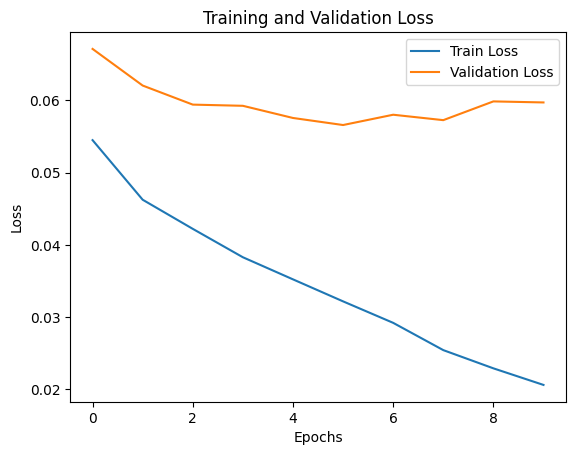


=== Temperature 0.7 ===
 the thee ntarel there oung parend tos the engeratining cane nenengpal compus. leeten and tours si acant sencaty opre ousin at congeractey enerat onen thare tor terrs corarent used fout the ours. genuse co

=== Temperature 1.0 ===
 the for euranic fourtinis compal sedc forpre ust corpreqt ure carde tor xen teyal lecuse!t gene sheylharr acter feretu cherarcteer erendk fometins trais ous. fog ton panglllyletis thaball sis. tis am teen

=== Temperature 1.2 ===
 the nenghss. fha.wracte!r nomrmtzhkr at conpeqish a tomprik tiis incs aanmyw gereteratevc untaersiretus y fode tw ohracan. co aretrare! reetyrathe se heytheral eniu chapus.d led. ctornius  seainn goel the


In [4]:
# char_rnn.py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt

# -------------------------
# 1. Load text corpus
# -------------------------
# Replace 'sample.txt' with any public-domain text (~50–200 KB)
with open('sample.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()  # lowercase for simplicity

# Remove unwanted characters (optional)
text = ''.join(c for c in text if c.isprintable())

# Vocabulary and mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}
# Encode full text
encoded_text = np.array([char2idx[c] for c in text])
print(f"Corpus length: {len(text)}, Vocab size: {vocab_size}")

# -------------------------
# 2. Create sequences
# -------------------------
seq_length = 50
step = 1
inputs, targets = [], []
for i in range(0, len(encoded_text) - seq_length, step):
    inputs.append(encoded_text[i:i+seq_length])
    targets.append(encoded_text[i+seq_length])

inputs = torch.tensor(np.array(inputs), dtype=torch.long)
targets = torch.tensor(np.array(targets), dtype=torch.long)
print("Input shape:", inputs.shape, "Target shape:", targets.shape)

# -------------------------
# 3. Define model
# -------------------------
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # last time step
        return out, hidden

# -------------------------
# 4. Hyperparameters
# -------------------------
embed_size = 128
hidden_size = 256
batch_size = 64
epochs = 10
lr = 0.002

model = CharRNN(vocab_size, embed_size, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
# -------------------------
# 5. Train / Validation split
# -------------------------
dataset = list(zip(inputs, targets))
random.shuffle(dataset)
split_idx = int(len(dataset) * 0.9)
train_data = dataset[:split_idx]
val_data = dataset[split_idx:]

train_losses = []
val_losses = []

# -------------------------
# 6. Training loop
# -------------------------
for epoch in range(1, epochs+1):
    # Training
    random.shuffle(train_data)
    total_loss = 0
    for i in range(0, len(train_data), batch_size):
        batch = train_data[i:i+batch_size]
        x_batch = torch.stack([b[0] for b in batch])
        y_batch = torch.tensor([b[1] for b in batch], dtype=torch.long)

        optimizer.zero_grad()
        out, _ = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_data)
    train_losses.append(avg_train_loss)

    # Validation
    with torch.no_grad():
        total_val_loss = 0
        for i in range(0, len(val_data), batch_size):
            batch = val_data[i:i+batch_size]
            x_batch = torch.stack([b[0] for b in batch])
            y_batch = torch.tensor([b[1] for b in batch], dtype=torch.long)
            out, _ = model(x_batch)
            loss = criterion(out, y_batch)
            total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_data)
        val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
# -------------------------
# 7. Plot loss curves
# -------------------------
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# -------------------------
# 8. Text generation
# -------------------------
def generate_text(model, start_seq, length=200, temperature=1.0):
    model.eval()
    generated = start_seq
    input_seq = torch.tensor([char2idx[c] for c in start_seq], dtype=torch.long).unsqueeze(0)
    hidden = None
    for _ in range(length):
        out, hidden = model(input_seq, hidden)
        probs = torch.softmax(out / temperature, dim=-1).detach().numpy().flatten()
        char_idx = np.random.choice(len(probs), p=probs)
        generated += idx2char[char_idx]
        input_seq = torch.tensor([[char_idx]], dtype=torch.long)
    return generated

# Generate samples with different temperatures
start_seq = "the "
print("\n=== Temperature 0.7 ===\n", generate_text(model, start_seq, 200, temperature=0.7))
print("\n=== Temperature 1.0 ===\n", generate_text(model, start_seq, 200, temperature=1.0))
print("\n=== Temperature 1.2 ===\n", generate_text(model, start_seq, 200, temperature=1.2))


Input Tokens:
 tensor([[13, 19, 20, 18,  0],
        [36,  3, 28, 22,  0],
        [ 6, 18, 15,  2,  0],
        [23, 16, 29, 15, 11],
        [ 4, 12, 22, 10,  0],
        [30, 21, 35,  7,  0],
        [13,  8, 18, 26, 33],
        [ 5, 31, 15, 14,  0],
        [25, 24, 17, 27,  0],
        [34, 15,  1, 32,  9]])
Shape: torch.Size([10, 5])

Final Contextual Embeddings Shape: torch.Size([10, 5, 32])

Sample Embedding for first sentence:
 tensor([[-1.3422e+00,  5.9908e-01, -2.4770e+00,  2.7047e-01,  2.2476e-03,
          3.3782e-01, -2.1396e+00,  1.3594e+00,  6.9069e-01,  1.6101e-01,
         -4.3949e-01,  1.7904e-01,  1.1256e+00,  1.0697e+00, -1.8618e-01,
         -9.6969e-02, -1.1997e+00,  3.2099e-01, -8.6981e-02,  1.8020e-01,
          8.7594e-02,  1.2009e-01, -1.2152e+00,  1.6954e+00, -1.1330e+00,
         -3.4049e-01, -1.0038e+00,  4.7600e-01,  9.5142e-01, -4.1138e-01,
          4.3099e-01,  2.0144e+00],
        [-3.4935e-01,  8.6416e-01,  5.7845e-01,  1.5703e+00, -2.1283e-01,
    

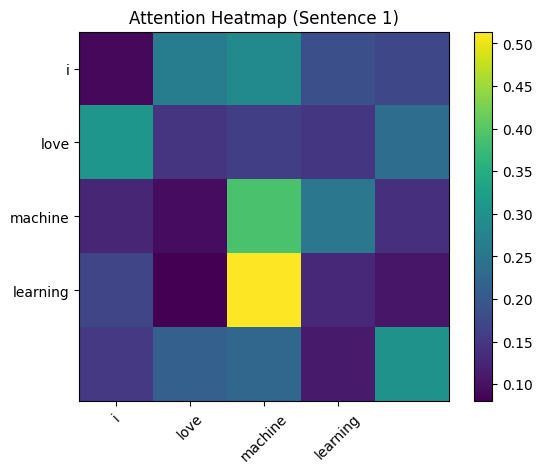

In [5]:
# mini_transformer_encoder.py

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Small Dataset (10 sentences)
# -------------------------
sentences = [
    "i love machine learning",
    "transformers are powerful models",
    "deep learning is amazing",
    "natural language processing is fun",
    "attention helps models focus",
    "pytorch makes training easy",
    "i enjoy learning new things",
    "data science is interesting",
    "neural networks learn patterns",
    "this is a simple example"
]

# -------------------------
# 2. Tokenization
# -------------------------
# Build vocabulary
words = set()
for sent in sentences:
    words.update(sent.split())

word2idx = {w: i+1 for i, w in enumerate(sorted(words))}
word2idx["<pad>"] = 0
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(word2idx)

# Convert sentences to token indices
max_len = max(len(s.split()) for s in sentences)

tokenized = []
for sent in sentences:
    tokens = [word2idx[w] for w in sent.split()]
    # pad
    tokens += [0] * (max_len - len(tokens))
    tokenized.append(tokens)

input_tensor = torch.tensor(tokenized)

print("Input Tokens:\n", input_tensor)
print("Shape:", input_tensor.shape)

# -------------------------
# 3. Positional Encoding
# -------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -------------------------
# 4. Transformer Encoder Block
# -------------------------
class MiniTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, d_ff=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)

        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        # Embedding + Positional Encoding
        emb = self.embedding(x)
        emb = self.pos_encoding(emb)

        # Self-attention
        attn_output, attn_weights = self.attention(emb, emb, emb)

        # Add & Norm
        x = self.norm1(emb + attn_output)

        # Feed-forward
        ff_output = self.ff(x)

        # Add & Norm
        out = self.norm2(x + ff_output)

        return out, attn_weights

# -------------------------
# 5. Run Model
# -------------------------
model = MiniTransformerEncoder(vocab_size)

output, attn_weights = model(input_tensor)

print("\nFinal Contextual Embeddings Shape:", output.shape)
print("\nSample Embedding for first sentence:\n", output[0])

# -------------------------
# 6. Attention Heatmap
# -------------------------
# Visualize attention of first sentence
attn = attn_weights[0].detach().numpy()

plt.imshow(attn, cmap='viridis')
plt.colorbar()
plt.title("Attention Heatmap (Sentence 1)")

words_list = sentences[0].split()
plt.xticks(range(len(words_list)), words_list, rotation=45)
plt.yticks(range(len(words_list)), words_list)

plt.show()


In [6]:
# scaled_dot_product_attention.py

import torch
import torch.nn.functional as F
import numpy as np

# -------------------------
# 1. Scaled Dot-Product Attention Function
# -------------------------
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)  # dimension of keys

    # Step 1: Compute raw attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1))  # QK^T

    # Step 2: Scale
    scaled_scores = scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

    # Step 3: Softmax
    attn_weights = F.softmax(scaled_scores, dim=-1)

    # Step 4: Multiply with V
    output = torch.matmul(attn_weights, V)

    return scores, scaled_scores, attn_weights, output

# -------------------------
# 2. Generate Random Q, K, V
# -------------------------
batch_size = 1
seq_len = 4
d_k = 8

torch.manual_seed(42)

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

print("Q:\n", Q)
print("\nK:\n", K)
print("\nV:\n", V)

# -------------------------
# 3. Compute Attention
# -------------------------
scores, scaled_scores, attn_weights, output = scaled_dot_product_attention(Q, K, V)
# -------------------------
# 4. Without Scaling (for comparison)
# -------------------------
raw_scores = torch.matmul(Q, K.transpose(-2, -1))
attn_no_scale = F.softmax(raw_scores, dim=-1)

# -------------------------
# 5. Print Results
# -------------------------
np.set_printoptions(precision=3, suppress=True)

print("\n==============================")
print("Raw Attention Scores (QK^T):")
print(scores.detach().numpy())

print("\nScaled Scores (QK^T / sqrt(d_k)):")
print(scaled_scores.detach().numpy())

print("\n==============================")
print("Softmax WITHOUT scaling:")
print(attn_no_scale.detach().numpy())

print("\nSoftmax WITH scaling:")
print(attn_weights.detach().numpy())

print("\n==============================")
print("Attention Output (Weighted Sum of V):")
print(output.detach().numpy())

# -------------------------
# 6. Stability Check
# -------------------------
print("\n==============================")
print("Stability Check:")

print("\nMax value BEFORE scaling:", torch.max(scores).item())
print("Max value AFTER scaling:", torch.max(scaled_scores).item())

print("\nSoftmax distribution WITHOUT scaling:")
print(attn_no_scale[0][0])

print("\nSoftmax distribution WITH scaling:")
print(attn_weights[0][0])


Q:
 tensor([[[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431,
          -1.6047],
         [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,
           0.7624],
         [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,
           1.6806],
         [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,
           0.8599]]])

K:
 tensor([[[-1.3847, -0.8712, -0.2234,  1.7174,  0.3189, -0.4245,  0.3057,
          -0.7746],
         [-1.5576,  0.9956, -0.8798, -0.6011, -1.2742,  2.1228, -1.2347,
          -0.4879],
         [-0.9138, -0.6581,  0.0780,  0.5258, -0.4880,  1.1914, -0.8140,
          -0.7360],
         [-1.4032,  0.0360, -0.0635,  0.6756, -0.0978,  1.8446, -1.1845,
           1.3835]]])

V:
 tensor([[[ 1.4451,  0.8564,  2.2181,  0.5232,  0.3466, -0.1973, -1.0546,
           1.2780],
         [-0.1722,  0.5238,  0.0566,  0.4263,  0.5750, -0.6417, -2.2064,
          -0.7508],
         [ 0.0109, -0.3387, -1.3407, -0.5854,  0.536